# Support Vector Machine (SVM)
### Finding the Widest Street Between Two Classes

A Support Vector Machine is a **maximum-margin classifier**: given two classes of points, it finds the hyperplane that separates them with the *largest possible gap*. The points closest to this boundary — the **support vectors** — are the only ones that matter for defining it.

This notebook builds an SVM from scratch using subgradient descent on the hinge loss, visualizes the margin and decision boundary, and explores the key regularization hyperparameter $C$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import ipywidgets as widgets
from IPython.display import display

rng = np.random.default_rng(42)

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f8f8f8",
    "axes.grid":         True,
    "grid.color":        "white",
    "grid.linewidth":    1.2,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
})

## 1 · The Big Idea: Maximum Margin Separation

---

Imagine two groups of points on a 2D plane. Many lines can separate them — so **which one should we pick?**

The SVM's answer: the one that is **farthest from both groups**. Think of it as finding the widest possible "street" between the two classes.

```
    Class –1           Street / Margin             Class +1
      ●  ●                  |   |                   ○  ○
        ●          ← gap → [boundary] ← gap →      ○
      ●                     |   |                      ○  ○
                         gutter  gutter
```

- The **decision boundary** is the center line of the street: $\mathbf{w}^T \mathbf{x} + b = 0$  
- The **gutters** are at $\mathbf{w}^T \mathbf{x} + b = +1$ and $\mathbf{w}^T \mathbf{x} + b = -1$  
- The **margin** is the width of the street: $\dfrac{2}{\|\mathbf{w}\|}$  
- The **support vectors** are the points sitting exactly on the gutters — the only training points that define the boundary

> **Key insight:** Maximizing the margin is equivalent to minimizing $\|\mathbf{w}\|$. A wider street means a smaller weight vector norm.

## 2 · Mathematical Formulation

---

### Notation

| Symbol | Meaning |
|--------|---------|
| $\mathbf{x}_i \in \mathbb{R}^d$ | Feature vector for sample $i$ |
| $y_i \in \{-1, +1\}$ | Class label (SVM uses ±1, not 0/1) |
| $\mathbf{w} \in \mathbb{R}^d$ | Weight vector (normal to the hyperplane) |
| $b \in \mathbb{R}$ | Bias / intercept |
| $C > 0$ | Regularization strength |
| $\xi_i \geq 0$ | Slack variable (how far a point is inside the margin) |

---

### Hard-Margin SVM (linearly separable data)

Find $\mathbf{w}$ and $b$ to:

$$\min_{\mathbf{w}, b} \; \frac{1}{2} \|\mathbf{w}\|^2$$

$$\text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 \quad \forall\, i$$

The constraint says: every point must be on the correct side of its gutter line (functional margin ≥ 1).

---

### Soft-Margin SVM (allows some misclassification)

Real data is rarely perfectly separable. We introduce **slack variables** $\xi_i$ that let points violate the margin:

$$\min_{\mathbf{w}, b, \boldsymbol{\xi}} \; \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{n} \xi_i$$

$$\text{subject to} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0 \quad \forall\, i$$

The hyperparameter $C$ controls the **margin vs. error tradeoff**:
- **Large $C$**: penalize violations heavily → narrow margin, fewer errors on training data
- **Small $C$**: tolerate violations → wide margin, more robust to noise

---

### Unconstrained (Hinge Loss) Formulation

We can eliminate the constraints by absorbing $\xi_i$ into the loss function. Substituting $\xi_i = \max(0, 1 - y_i(\mathbf{w}^T\mathbf{x}_i + b))$ gives:

$$\min_{\mathbf{w}, b} \; \underbrace{\frac{1}{2n} \|\mathbf{w}\|^2}_{\text{regularization}} + \underbrace{C \cdot \frac{1}{n}\sum_{i=1}^{n} \max\!\left(0,\; 1 - y_i(\mathbf{w}^T \mathbf{x}_i + b)\right)}_{\text{hinge loss}}$$

> **Key insight:** A point **inside the margin or misclassified** contributes to the loss. Correctly classified points **outside the margin** contribute zero — they don't affect the boundary at all!

## 3 · Dataset

---

We generate a **2D binary classification** dataset — two Gaussian blobs with a gap between them.  
2D lets us visualize the decision boundary, margin, and support vectors directly.

Training samples : 96  (+1: 46, -1: 50)
Test samples     : 24   (+1: 14, -1: 10)


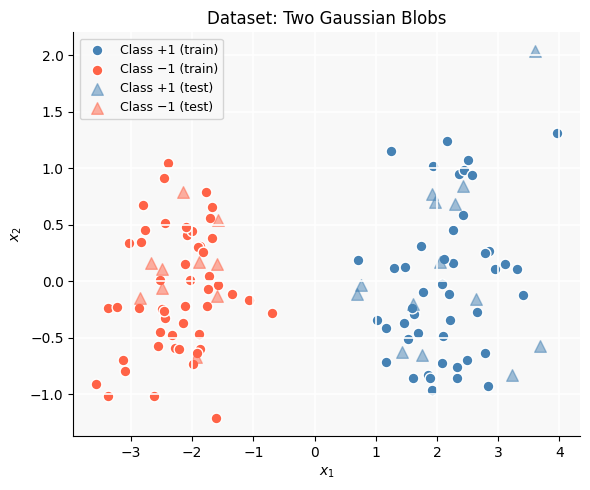

In [2]:
def make_blobs(n=100, sep=2.0, noise=0.5):
    """Two Gaussian blobs centered at ±sep/2 along the x-axis."""
    n_each = n // 2
    X_neg = rng.normal(loc=[-sep, 0], scale=noise, size=(n_each, 2))
    X_pos = rng.normal(loc=[ sep, 0], scale=noise, size=(n_each, 2))
    X = np.vstack([X_neg, X_pos])
    y = np.hstack([-np.ones(n_each), np.ones(n_each)])
    return X, y

X, y = make_blobs(n=120, sep=2.2, noise=0.7)

# Train / test split (80/20)
idx = rng.permutation(len(y))
split = int(0.8 * len(y))
X_train, X_test = X[idx[:split]], X[idx[split:]]
y_train, y_test = y[idx[:split]], y[idx[split:]]

print(f"Training samples : {len(X_train)}  (+1: {(y_train==1).sum()}, -1: {(y_train==-1).sum()})")
print(f"Test samples     : {len(X_test)}   (+1: {(y_test==1).sum()}, -1: {(y_test==-1).sum()})")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_train[y_train== 1, 0], X_train[y_train== 1, 1],
           color="steelblue", edgecolor="white", s=60, label="Class +1 (train)")
ax.scatter(X_train[y_train==-1, 0], X_train[y_train==-1, 1],
           color="tomato",    edgecolor="white", s=60, label="Class −1 (train)")
ax.scatter(X_test[y_test== 1, 0],  X_test[y_test== 1, 1],
           color="steelblue", marker="^", s=70, alpha=0.5, label="Class +1 (test)")
ax.scatter(X_test[y_test==-1, 0],  X_test[y_test==-1, 1],
           color="tomato",    marker="^", s=70, alpha=0.5, label="Class −1 (test)")
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Dataset: Two Gaussian Blobs")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 4 · The Hinge Loss

---

The hinge loss for a single sample with label $y \in \{-1, +1\}$ and raw score $s = \mathbf{w}^T\mathbf{x} + b$ is:

$$\ell_{\text{hinge}}(y, s) = \max(0,\; 1 - y \cdot s)$$

The term $y \cdot s$ is called the **functional margin** — it measures how correctly (and confidently) a sample is classified:

| Situation | $y \cdot s$ | Loss |
|-----------|------------|------|
| Correct, outside margin | $> 1$ | $0$ |
| Correct, on the gutter | $= 1$ | $0$ |
| Correct, inside margin | $0 < y \cdot s < 1$ | $1 - y\cdot s > 0$ |
| Wrong side (misclassified) | $< 0$ | $> 1$ |

> **Key insight:** The hinge loss is zero once a point is correctly classified AND outside the margin. This is why only support vectors matter — all other points have zero gradient and don't affect the solution.

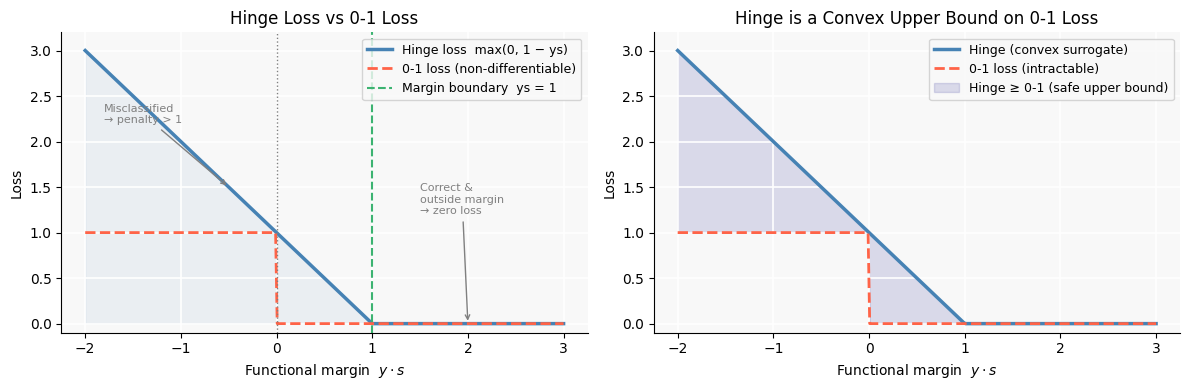

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: hinge loss vs functional margin
ys_vals = np.linspace(-2, 3, 300)
hinge   = np.maximum(0, 1 - ys_vals)
zero_one = (ys_vals < 0).astype(float)  # 0-1 loss for comparison

ax = axes[0]
ax.plot(ys_vals, hinge,    color="steelblue", lw=2.5, label="Hinge loss  max(0, 1 − ys)")
ax.plot(ys_vals, zero_one, color="tomato",    lw=2,   linestyle="--", label="0-1 loss (non-differentiable)")
ax.axvline(0, color="gray", lw=1, linestyle=":")
ax.axvline(1, color="mediumseagreen", lw=1.5, linestyle="--", label="Margin boundary  ys = 1")
ax.fill_between(ys_vals, hinge, alpha=0.08, color="steelblue")
ax.set_xlabel("Functional margin  $y \\cdot s$")
ax.set_ylabel("Loss")
ax.set_title("Hinge Loss vs 0-1 Loss")
ax.legend(fontsize=9)
ax.set_ylim(-0.1, 3.2)
ax.annotate("Correct &\noutside margin\n→ zero loss", xy=(2, 0), xytext=(1.5, 1.2),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8, color="gray")
ax.annotate("Misclassified\n→ penalty > 1", xy=(-0.5, 1.5), xytext=(-1.8, 2.2),
            arrowprops=dict(arrowstyle="->", color="gray"), fontsize=8, color="gray")

# Right: hinge is an upper bound on 0-1
ax2 = axes[1]
ax2.plot(ys_vals, hinge,    color="steelblue", lw=2.5, label="Hinge (convex surrogate)")
ax2.plot(ys_vals, zero_one, color="tomato",    lw=2,   linestyle="--", label="0-1 loss (intractable)")
ax2.fill_between(ys_vals, zero_one, hinge, where=(hinge >= zero_one),
                 alpha=0.12, color="navy", label="Hinge ≥ 0-1 (safe upper bound)")
ax2.set_xlabel("Functional margin  $y \\cdot s$")
ax2.set_ylabel("Loss")
ax2.set_title("Hinge is a Convex Upper Bound on 0-1 Loss")
ax2.legend(fontsize=9)
ax2.set_ylim(-0.1, 3.2)

plt.tight_layout(); plt.show()

## 5 · Optimization: Subgradient Descent

---

The hinge loss is **convex but not differentiable** at $1 - ys = 0$. We use the **subgradient** instead of the true gradient.

### Full Objective

$$\mathcal{L}(\mathbf{w}, b) = \frac{1}{2n}\|\mathbf{w}\|^2 + \frac{C}{n}\sum_{i=1}^n \max(0, 1 - y_i s_i)$$

where $s_i = \mathbf{w}^T \mathbf{x}_i + b$.

### Subgradient Derivation

**Regularization term** — standard gradient:

$$\frac{\partial}{\partial \mathbf{w}} \frac{1}{2n}\|\mathbf{w}\|^2 = \frac{\mathbf{w}}{n}$$

**Hinge loss term** — subgradient of $\max(0, 1 - y_i s_i)$:

$$\partial_{s_i} \max(0, 1 - y_i s_i) = \begin{cases} 0 & \text{if } y_i s_i > 1 \\ -y_i & \text{if } y_i s_i \leq 1 \end{cases}$$

Chain rule gives the gradient w.r.t. $\mathbf{w}$ for a single sample $i$:

$$\partial_{\mathbf{w}} \ell_i = \begin{cases} \mathbf{0} & \text{if } y_i s_i > 1 \quad \text{(correctly classified, outside margin)} \\ -y_i \mathbf{x}_i & \text{if } y_i s_i \leq 1 \quad \text{(in margin or misclassified)} \end{cases}$$

### Full Subgradients (averaged over the batch)

$$\nabla_{\mathbf{w}} \mathcal{L} = \frac{\mathbf{w}}{n} + \frac{C}{n} \sum_{i:\, y_i s_i \leq 1} (-y_i \mathbf{x}_i)$$

$$\nabla_{b} \mathcal{L} = \frac{C}{n} \sum_{i:\, y_i s_i \leq 1} (-y_i)$$

### Update Rule

$$\mathbf{w} \leftarrow \mathbf{w} - \eta \nabla_{\mathbf{w}} \mathcal{L}, \qquad b \leftarrow b - \eta \nabla_b \mathcal{L}$$

In [4]:
class SVM:
    """Soft-margin SVM trained via full-batch subgradient descent."""

    def __init__(self, C=1.0, lr=0.01, n_epochs=500):
        self.C = C
        self.lr = lr
        self.n_epochs = n_epochs
        self.w = None
        self.b = None
        self.loss_history = []

    def _objective(self, X, y):
        n = len(y)
        scores = X @ self.w + self.b          # shape (n,)
        margins = y * scores                  # functional margins
        hinge = np.maximum(0, 1 - margins)
        reg   = 0.5 / n * np.dot(self.w, self.w)
        return reg + self.C / n * hinge.sum()

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0

        for _ in range(self.n_epochs):
            scores  = X @ self.w + self.b
            margins = y * scores

            # Mask: samples inside or on wrong side of margin
            mask = (margins <= 1)

            # Subgradients
            grad_w = self.w / n - self.C / n * (y[mask, None] * X[mask]).sum(axis=0)
            grad_b =            - self.C / n * y[mask].sum()

            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

            self.loss_history.append(self._objective(X, y))

        return self

    def decision_function(self, X):
        return X @ self.w + self.b

    def predict(self, X):
        return np.sign(self.decision_function(X))

    @property
    def margin_width(self):
        w_norm = np.linalg.norm(self.w)
        return 2 / w_norm if w_norm > 0 else np.inf

print("SVM class defined.")

SVM class defined.


## 6 · Training Loop + Loss Curve

---

We train with $C = 1.0$ and a fixed learning rate. After training we inspect the learned parameters and plot how the objective decreases over epochs.

Learned w        : [1.0446, 0.1130]
Learned b        : 0.0359
||w||            : 1.0507
Margin width     : 1.9035
Final loss       : 0.0107


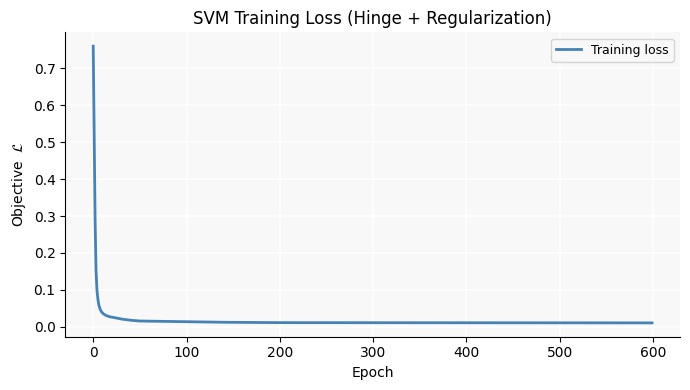

In [5]:
svm = SVM(C=1.0, lr=0.05, n_epochs=600)
svm.fit(X_train, y_train)

print(f"Learned w        : [{svm.w[0]:.4f}, {svm.w[1]:.4f}]")
print(f"Learned b        : {svm.b:.4f}")
print(f"||w||            : {np.linalg.norm(svm.w):.4f}")
print(f"Margin width     : {svm.margin_width:.4f}")
print(f"Final loss       : {svm.loss_history[-1]:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(svm.loss_history, color="steelblue", lw=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("Objective  $\\mathcal{L}$")
ax.set_title("SVM Training Loss (Hinge + Regularization)")
ax.legend(["Training loss"], fontsize=9)
plt.tight_layout(); plt.show()

## 7 · Decision Boundary, Margin & Support Vectors

---

With the learned $\mathbf{w}$ and $b$ we can draw:
- The **decision boundary**: $\mathbf{w}^T\mathbf{x} + b = 0$
- The **margin boundaries** (gutters): $\mathbf{w}^T\mathbf{x} + b = \pm 1$
- The **support vectors**: training points that satisfy $y_i(\mathbf{w}^T\mathbf{x}_i + b) \leq 1$ (on or inside the margin)

/Users/wanchuan/ml-learn/.venv/lib/python3.13/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/Users/wanchuan/ml-learn/.venv/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


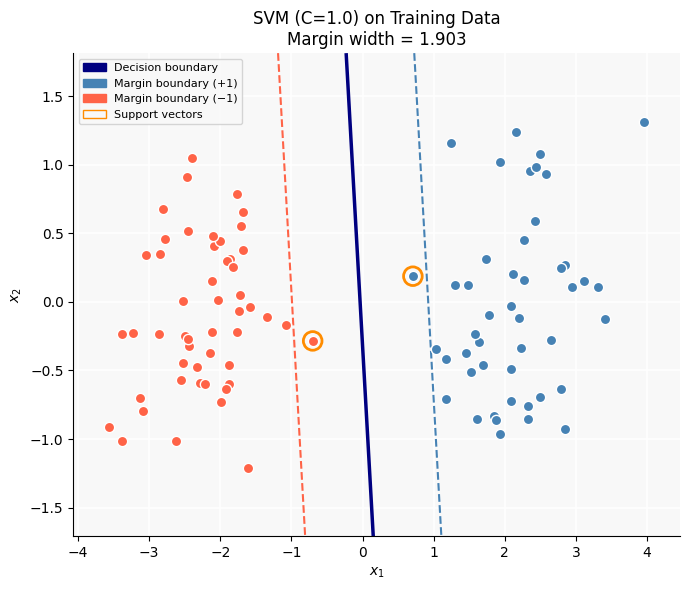

In [6]:
def plot_svm(svm, X, y, ax, title="SVM Decision Boundary"):
    """Draw decision boundary, margin, support vectors, and decision region."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Soft decision regions
    cmap_bg = ListedColormap(["#ffd6d6", "#d6e8ff"])
    ax.contourf(xx, yy, Z, levels=[-np.inf, 0, np.inf], cmap=cmap_bg, alpha=0.4)

    # Decision boundary and margin lines
    ax.contour(xx, yy, Z, levels=[-1, 0, 1],
               linestyles=["--", "-", "--"],
               colors=["tomato", "navy", "steelblue"],
               linewidths=[1.5, 2.5, 1.5])

    # Training points
    ax.scatter(X[y== 1, 0], X[y== 1, 1], color="steelblue", edgecolor="white",
               s=55, zorder=3, label="Class +1")
    ax.scatter(X[y==-1, 0], X[y==-1, 1], color="tomato",    edgecolor="white",
               s=55, zorder=3, label="Class −1")

    # Support vectors: functional margin ≤ 1
    functional_margins = y * svm.decision_function(X)
    sv_mask = functional_margins <= 1 + 1e-4
    ax.scatter(X[sv_mask, 0], X[sv_mask, 1],
               s=180, facecolors="none", edgecolors="darkorange", lw=2,
               zorder=4, label=f"Support vectors ({sv_mask.sum()})")

    # Margin width annotation
    margin_w = svm.margin_width
    ax.set_title(f"{title}\nMargin width = {margin_w:.3f}")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.legend(fontsize=8, loc="upper left")

    # Legend for boundary lines
    bd_patch = mpatches.Patch(color="navy",     label="Decision boundary")
    mg_patch = mpatches.Patch(color="steelblue", label="Margin boundary (+1)")
    mn_patch = mpatches.Patch(color="tomato",    label="Margin boundary (−1)")
    ax.legend(handles=[bd_patch, mg_patch, mn_patch,
                        mpatches.Patch(color="darkorange", fill=False, label="Support vectors")],
              fontsize=8, loc="upper left")


fig, ax = plt.subplots(figsize=(7, 6))
plot_svm(svm, X_train, y_train, ax, title="SVM (C=1.0) on Training Data")
plt.tight_layout(); plt.show()

## 8 · Evaluation

---

We evaluate on the held-out test set using **accuracy** and a **confusion matrix**.  
Since labels are $\{-1, +1\}$, a prediction is correct when $\hat{y}_i = y_i$.

Train accuracy : 1.000
Test  accuracy : 1.000


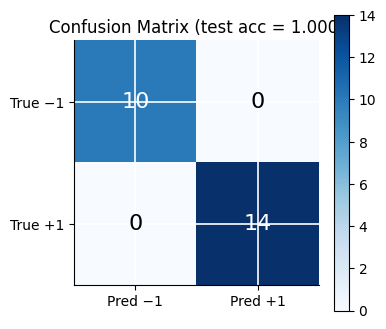

In [7]:
y_pred_train = svm.predict(X_train)
y_pred_test  = svm.predict(X_test)

train_acc = (y_pred_train == y_train).mean()
test_acc  = (y_pred_test  == y_test ).mean()
print(f"Train accuracy : {train_acc:.3f}")
print(f"Test  accuracy : {test_acc:.3f}")

# Confusion matrix (rows = true, cols = predicted; labels [-1, +1])
def confusion_matrix_2class(y_true, y_pred):
    classes = [-1, 1]
    cm = np.zeros((2, 2), dtype=int)
    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm[i, j] = ((y_true == c_true) & (y_pred == c_pred)).sum()
    return cm

cm = confusion_matrix_2class(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred −1", "Pred +1"])
ax.set_yticklabels(["True −1", "True +1"])
ax.set_title(f"Confusion Matrix (test acc = {test_acc:.3f})")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                fontsize=16, color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

## 9 · Effect of the Regularization Parameter $C$

---

$C$ is the single most important hyperparameter in an SVM.

$$\mathcal{L} = \underbrace{\frac{1}{2n}\|\mathbf{w}\|^2}_{\text{wants large margin}} + C \cdot \underbrace{\frac{1}{n}\sum_i \xi_i}_{\text{wants few violations}}$$

| $C$ | Effect | Visual signature |
|-----|--------|-----------------|
| Very small (e.g. 0.01) | Regularization dominates → huge margin, many violations tolerated | Wide gap, many points inside margin |
| Medium (e.g. 1.0) | Balanced | Moderate margin |
| Very large (e.g. 100) | Hinge loss dominates → narrow margin, near-zero training error | Tight gap, few support vectors |

Let's train four models and compare them side-by-side.

/Users/wanchuan/ml-learn/.venv/lib/python3.13/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin
/Users/wanchuan/ml-learn/.venv/lib/python3.13/site-packages/matplotlib/colors.py:2295: RuntimeWarning: invalid value encountered in divide
  resdat /= (vmax - vmin)


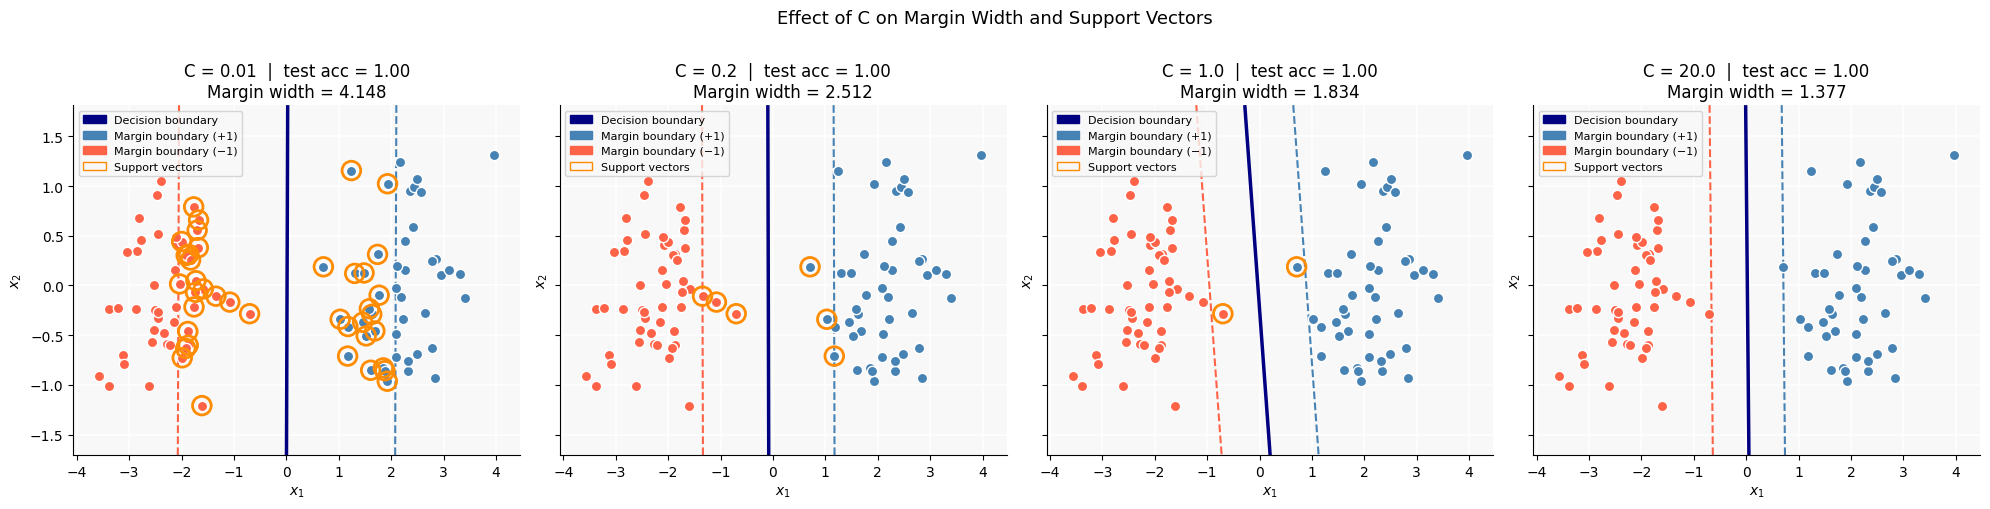


Summary:
       C      Margin    #SVs   Train acc   Test acc
    0.01      4.1480      40       1.000      1.000
    0.20      2.5116       6       1.000      1.000
    1.00      1.8336       2       1.000      1.000
   20.00      1.3768       0       1.000      1.000


In [8]:
C_values = [0.01, 0.2, 1.0, 20.0]
models = {}
for C in C_values:
    m = SVM(C=C, lr=0.05, n_epochs=800)
    m.fit(X_train, y_train)
    models[C] = m

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

for ax, C in zip(axes, C_values):
    m = models[C]
    acc = (m.predict(X_test) == y_test).mean()
    plot_svm(m, X_train, y_train, ax, title=f"C = {C}  |  test acc = {acc:.2f}")

plt.suptitle("Effect of C on Margin Width and Support Vectors", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print("\nSummary:")
print(f"{'C':>8}  {'Margin':>10}  {'#SVs':>6}  {'Train acc':>10}  {'Test acc':>9}")
for C in C_values:
    m = models[C]
    fm = y_train * m.decision_function(X_train)
    n_sv = (fm <= 1 + 1e-4).sum()
    tr_acc = (m.predict(X_train) == y_train).mean()
    te_acc = (m.predict(X_test)  == y_test ).mean()
    print(f"{C:>8.2f}  {m.margin_width:>10.4f}  {n_sv:>6}  {tr_acc:>10.3f}  {te_acc:>9.3f}")

## 10 · Interactive Widget: Explore $C$ with a Slider

---

Use the slider to change $C$ and instantly see how the margin and decision boundary respond.

In [ ]:
def svm_widget(log_C):
    C = 10 ** log_C
    m = SVM(C=C, lr=0.05, n_epochs=600)
    m.fit(X_train, y_train)
    acc = (m.predict(X_test) == y_test).mean()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Left: decision boundary
    plot_svm(m, X_train, y_train, axes[0], title=f"C = {C:.3g}  |  test acc = {acc:.2f}")

    # Right: loss curve
    axes[1].plot(m.loss_history, color="steelblue", lw=2)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].set_title(f"Training Loss  (margin = {m.margin_width:.3f})")
    axes[1].legend([f"C = {C:.3g}"], fontsize=9)

    plt.tight_layout(); plt.show()

slider = widgets.FloatSlider(
    value=0.0, min=-2.0, max=2.0, step=0.25,
    description="log₁₀(C):",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="450px"),
)
widgets.interact(svm_widget, log_C=slider);

interactive(children=(FloatSlider(value=0.0, description='log₁₀(C):', layout=Layout(width='450px'), max=2.0, m…

## 11 · Summary

---

| Concept | Key Idea |
|---------|----------|
| **Maximum margin** | SVM finds the hyperplane with the largest gap between classes, measured as $\frac{2}{\|\mathbf{w}\|}$ |
| **Decision boundary** | Hyperplane $\mathbf{w}^T\mathbf{x} + b = 0$ divides the feature space |
| **Support vectors** | The training points closest to the boundary (functional margin ≤ 1); they fully define $\mathbf{w}$ and $b$ |
| **Hard-margin SVM** | Requires perfect linear separability; minimizes $\frac{1}{2}\|\mathbf{w}\|^2$ subject to $y_i s_i \geq 1$ |
| **Soft-margin SVM** | Allows slack $\xi_i$; adds a penalty $C\sum\xi_i$ to tolerate noise and overlap |
| **Hinge loss** | $\max(0, 1 - ys)$ — zero for correctly classified points outside the margin, linear penalty otherwise |
| **$C$ hyperparameter** | Trade-off: large $C$ → narrow margin + low training error; small $C$ → wide margin + more violations |
| **Subgradient descent** | Hinge is non-differentiable at the kink; we use subgradients — zero for non-support-vectors |
| **Sparsity** | Only support vectors have non-zero gradient contribution, making SVMs efficient and interpretable |
| **Labels convention** | SVM uses $y \in \{-1, +1\}$ so that $y \cdot s > 0$ means correct classification |